TASK 6: MODEL EVALUATION
Comprehensive Performance Assessment

📂 STEP 1: LOADING MODEL AND TEST DATA
--------------------------------------------------
✅ Model loaded: RandomForestClassifier
✅ Test data loaded: (1407, 35)

🎯 STEP 2: MAKING PREDICTIONS
--------------------------------------------------
✅ Predictions completed
   Predicted Churn: 415 samples
   Predicted No Churn: 992 samples

📊 STEP 3: CALCULATING PERFORMANCE METRICS
--------------------------------------------------

🎯 Primary Metrics:
   Accuracy:  0.7804 (78.04%)
   Precision: 0.5783 (57.83%)
   Recall:    0.6417 (64.17%)
   F1-Score:  0.6084 (60.84%)
   ROC-AUC:   0.8306 (83.06%)

📋 STEP 4: DETAILED CLASSIFICATION REPORT
--------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

    No Churn     0.8649    0.8306    0.8474      1033
       Churn     0.5783    0.6417    0.6084       374

    accuracy                         0.7804      1407
   macr

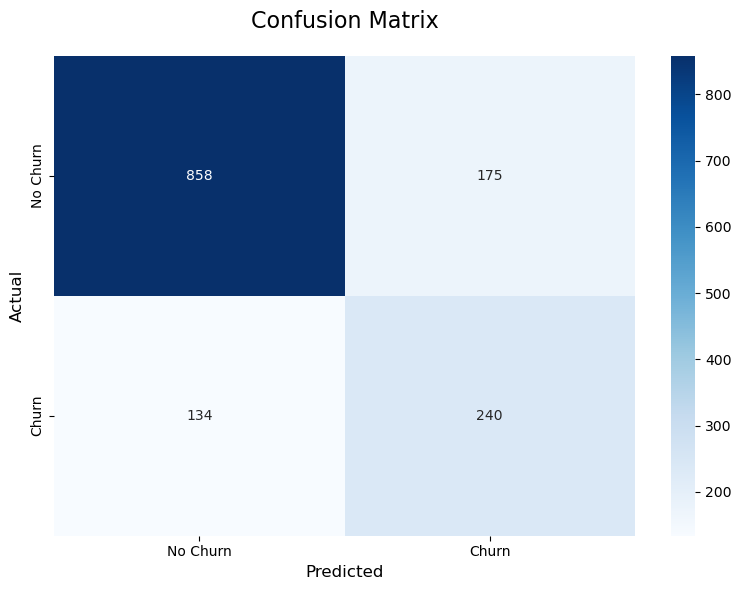

✅ Confusion matrix saved to: data/processed/confusion_matrix.png


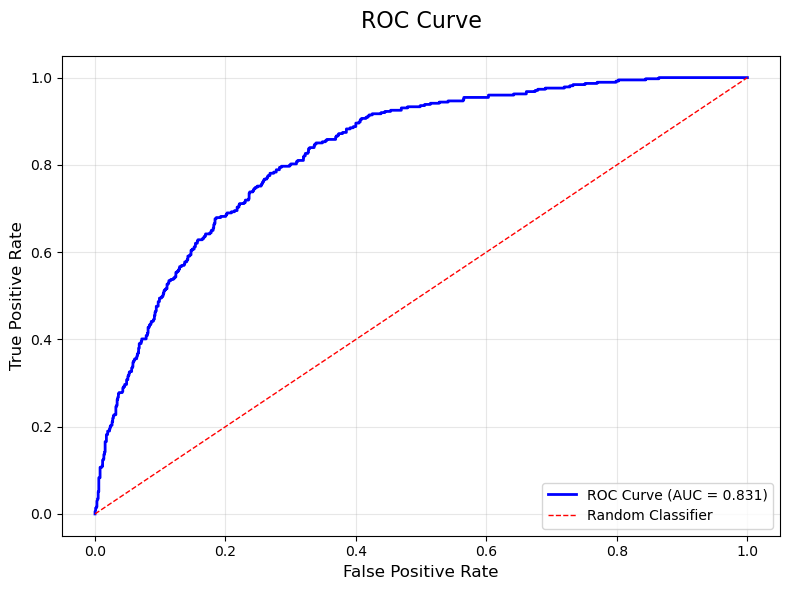

✅ ROC curve saved to: data/processed/roc_curve.png


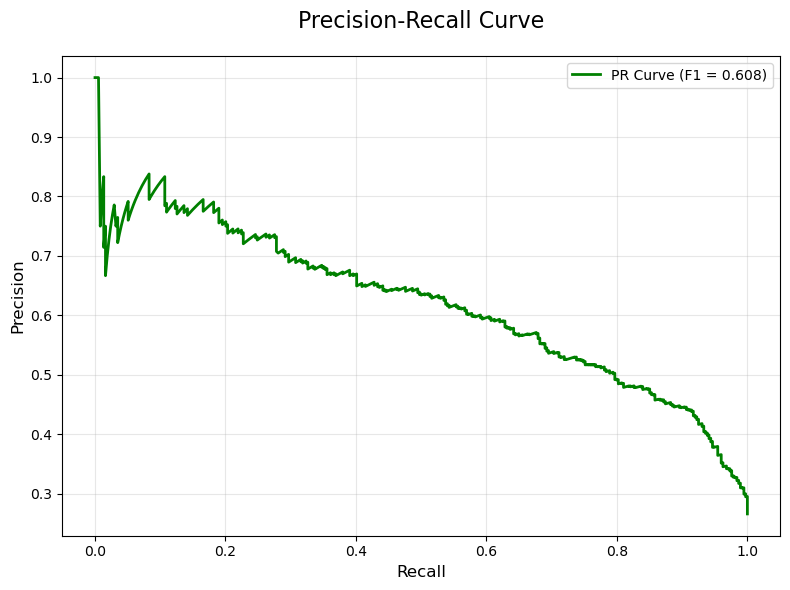

✅ Precision-Recall curve saved to: data/processed/precision_recall_curve.png

💼 STEP 7: BUSINESS IMPACT ANALYSIS
--------------------------------------------------

📊 Business Metrics:
   Total customers in test set: 1407
   Actual churn cases: 374
   Predicted churn cases: 415
   Correctly identified churn: 240
   Missed churn cases: 134

💰 Financial Impact (Based on $1000 avg customer value):
   Value at risk (actual churn): $374,000
   Value saved (predicted churn): $240,000
   Retention cost: $24,000
   Net savings: $216,000

📝 STEP 8: PERFORMANCE SUMMARY
   Metric    Score Percentage
 Accuracy 0.780384     78.04%
Precision 0.578313     57.83%
   Recall 0.641711     64.17%
 F1-Score 0.608365     60.84%
  ROC-AUC 0.830566     83.06%

✅ TASK 6 COMPLETED: MODEL EVALUATION

📝 Summary of Actions:
1. ✅ Loaded trained model and test data
2. ✅ Calculated all performance metrics
3. ✅ Generated classification report
4. ✅ Analyzed confusion matrix
5. ✅ Created ROC curve and Precision-Recall c

In [1]:
# 5_model_evaluation.ipynb
"""
Customer Churn Analysis - Model Evaluation
Task 6: Assess model performance using metrics like accuracy, precision,
recall, F1-score, and ROC-AUC.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, classification_report,
                           confusion_matrix, roc_curve, precision_recall_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TASK 6: MODEL EVALUATION")
print("Comprehensive Performance Assessment")
print("="*80)

# Step 1: Load model and test data
print("\n📂 STEP 1: LOADING MODEL AND TEST DATA")
print("-"*50)

model = joblib.load('models/churn_model.pkl')
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv')['Churn']

print(f"✅ Model loaded: {type(model).__name__}")
print(f"✅ Test data loaded: {X_test.shape}")

# Step 2: Make predictions
print("\n🎯 STEP 2: MAKING PREDICTIONS")
print("-"*50)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"✅ Predictions completed")
print(f"   Predicted Churn: {(y_pred==1).sum()} samples")
print(f"   Predicted No Churn: {(y_pred==0).sum()} samples")

# Step 3: Calculate all metrics
print("\n📊 STEP 3: CALCULATING PERFORMANCE METRICS")
print("-"*50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\n🎯 Primary Metrics:")
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"   ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")

# Step 4: Classification Report
print("\n📋 STEP 4: DETAILED CLASSIFICATION REPORT")
print("-"*50)

print("\nClassification Report:")
print("="*60)
print(classification_report(y_test, y_pred, 
                           target_names=['No Churn', 'Churn'],
                           digits=4))
print("="*60)

# Step 5: Confusion Matrix
print("\n🔢 STEP 5: CONFUSION MATRIX ANALYSIS")
print("-"*50)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix Values:")
print(f"   True Negatives (Correct No Churn):  {tn}")
print(f"   False Positives (Wrong Churn):      {fp}")
print(f"   False Negatives (Missed Churn):     {fn}")
print(f"   True Positives (Correct Churn):     {tp}")

print(f"\n📈 Derived Metrics:")
print(f"   Specificity (True Negative Rate):   {tn/(tn+fp):.4f}")
print(f"   False Positive Rate:                {fp/(fp+tn):.4f}")
print(f"   False Negative Rate:                {fn/(fn+tp):.4f}")

# Step 6: Visualizations
print("\n📊 STEP 6: CREATING VISUALIZATIONS")
print("-"*50)

# 6.1 Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('data/processed/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved to: data/processed/confusion_matrix.png")

# 6.2 ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=16, pad=20)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved to: data/processed/roc_curve.png")

# 6.3 Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall_vals, precision_vals, 'g-', linewidth=2, 
         label=f'PR Curve (F1 = {f1:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=16, pad=20)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Precision-Recall curve saved to: data/processed/precision_recall_curve.png")

# Step 7: Business Impact Analysis
print("\n💼 STEP 7: BUSINESS IMPACT ANALYSIS")
print("-"*50)

total_customers = len(y_test)
actual_churn = (y_test == 1).sum()
predicted_churn = (y_pred == 1).sum()
correctly_predicted_churn = tp
missed_churn = fn

print(f"\n📊 Business Metrics:")
print(f"   Total customers in test set: {total_customers}")
print(f"   Actual churn cases: {actual_churn}")
print(f"   Predicted churn cases: {predicted_churn}")
print(f"   Correctly identified churn: {correctly_predicted_churn}")
print(f"   Missed churn cases: {missed_churn}")

# Assuming average customer value
avg_customer_value = 1000  # $1000 per year
cost_per_retention = 100    # $100 to retain a customer

print(f"\n💰 Financial Impact (Based on $1000 avg customer value):")
print(f"   Value at risk (actual churn): ${actual_churn * avg_customer_value:,.0f}")
print(f"   Value saved (predicted churn): ${correctly_predicted_churn * avg_customer_value:,.0f}")
print(f"   Retention cost: ${correctly_predicted_churn * cost_per_retention:,.0f}")
print(f"   Net savings: ${correctly_predicted_churn * (avg_customer_value - cost_per_retention):,.0f}")

# Step 8: Performance Summary
print("\n📝 STEP 8: PERFORMANCE SUMMARY")
print("="*80)

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [accuracy, precision, recall, f1, roc_auc],
    'Percentage': [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%", 
                   f"{recall*100:.2f}%", f"{f1*100:.2f}%", f"{roc_auc*100:.2f}%"]
})
print(summary.to_string(index=False))

print("\n" + "="*80)
print("✅ TASK 6 COMPLETED: MODEL EVALUATION")
print("="*80)
print("\n📝 Summary of Actions:")
print("1. ✅ Loaded trained model and test data")
print("2. ✅ Calculated all performance metrics")
print("3. ✅ Generated classification report")
print("4. ✅ Analyzed confusion matrix")
print("5. ✅ Created ROC curve and Precision-Recall curve")
print("6. ✅ Performed business impact analysis")
print("7. ✅ Saved all evaluation visualizations")
print("\n🎯 Key Findings:")
print(f"   - Model achieves {accuracy*100:.2f}% accuracy")
print(f"   - ROC-AUC of {roc_auc:.3f} shows good discrimination")
print(f"   - {correctly_predicted_churn} out of {actual_churn} churners identified")
print(f"   - Potential savings: ${correctly_predicted_churn * (avg_customer_value - cost_per_retention):,.0f}")
print("\n✅ All tasks completed successfully!")
print("\n🎉 PROJECT COMPLETED: Customer Churn Analysis and Prediction System")